In [ ]:
from mask_generator import PerlinMaskGenerator, FreeFormMaskGenerator, ScratchMaskGenerator
import os
import cv2
import numpy as np
from tqdm.notebook import tqdm # استخدام tqdm الخاصة بالجوبيتر
from concurrent.futures import ThreadPoolExecutor

# ==========================================
# ⚙️ إعدادات التوليد (يمكنك تعديلها)
# ==========================================
NUM_MASKS_PER_TYPE = 1000            # عدد الأقنعة المراد توليدها لكل نوع (الإجمالي سيكون 3000)
BASE_OUTPUT_DIR = "dataset/masks"    # المجلد الرئيسي
IMG_HEIGHT = 224                     # ارتفاع القناع
IMG_WIDTH = 224                      # عرض القناع
NUM_WORKERS = os.cpu_count()         # استخدام جميع أنوية المعالج

# تعريف الأنواع والمولدات الخاصة بها
MASK_TYPES = {
    'perlin': (PerlinMaskGenerator, 1),   # (الكلاس, رقم تعريفي للبذرة العشوائية)
    'freeform': (FreeFormMaskGenerator, 2),
    'scratch': (ScratchMaskGenerator, 3)
}

def create_and_save_mask(args):
    """
    دالة تقوم بتوليد قناع واحد وحفظه.
    تستقبل args كـ (فهرس الصورة, اسم نوع القناع)
    """
    index, mask_type = args
    GeneratorClass, type_id = MASK_TYPES[mask_type]
    
    # 1. ضمان عشوائية مستقلة لكل صورة وكل نوع
    np.random.seed((os.getpid() * (int(index) + 1) * type_id) % 123456789)
    
    # 2. تهيئة المولد المناسب بناءً على النوع
    if mask_type == 'perlin':
        generator = GeneratorClass(min_scale=1, max_scale=4, octaves=3)
    else:
        generator = GeneratorClass() # المولدات الأخرى لا تحتاج مدخلات إجبارية حالياً
    
    # 3. توليد القناع
    mask = generator.generate_mask(height=IMG_HEIGHT, width=IMG_WIDTH)
    attempts = 0
    max_attempts = 10
    
    # حلقة تكرارية: طالما القناع أسود (أقصى قيمة فيه تساوي صفر)، أعد التوليد
    while np.max(mask) == 0 and attempts < max_attempts:
        attempts += 1
        mask = generator.generate_mask(height=IMG_HEIGHT, width=IMG_WIDTH)
    
    # 4. تحويل القيم وحفظ الصورة
    mask_uint8 = (mask * 255).astype(np.uint8)
    
    # مسار الحفظ (مثال: dataset/masks/perlin/mask_000000.png)
    output_dir = os.path.join(BASE_OUTPUT_DIR, mask_type)
    filename = os.path.join(output_dir, f"{mask_type}_{index:06d}.png")
    cv2.imwrite(filename, mask_uint8)
    
    return True

if __name__ == '__main__':
    print("="*50)
    print(f"🚀 بدء التوليد الشامل (All-in-One Offline Generation)")
    print(f"📁 المجلد الرئيسي: {BASE_OUTPUT_DIR}")
    print(f"🔢 الإجمالي: {NUM_MASKS_PER_TYPE * len(MASK_TYPES)} قناع ({NUM_MASKS_PER_TYPE} لكل نوع)")
    print(f"💻 عدد مسارات المعالجة (Threads): {NUM_WORKERS}")
    print("="*50)

    # تجهيز قائمة المهام (Tasks) وإنشاء المجلدات الفرعية
    tasks = []
    for mask_type in MASK_TYPES.keys():
        os.makedirs(os.path.join(BASE_OUTPUT_DIR, mask_type), exist_ok=True)
        for i in range(NUM_MASKS_PER_TYPE):
            tasks.append((i, mask_type))

    # تنفيذ المهام بالتوازي
    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        # استخدام إجمالي عدد المهام لشريط التقدم
        list(tqdm(executor.map(create_and_save_mask, tasks), total=len(tasks), desc="توليد الأقنعة"))

    print("\n✅ اكتمل التوليد بنجاح! تم حفظ جميع الأنواع في مجلداتها المستقلة.")

🚀 بدء التوليد الشامل (All-in-One Offline Generation)
📁 المجلد الرئيسي: dataset/masks
🔢 الإجمالي: 3000 قناع (1000 لكل نوع)
💻 عدد مسارات المعالجة (Threads): 8


توليد الأقنعة:   0%|          | 0/3000 [00:00<?, ?it/s]


✅ اكتمل التوليد بنجاح! تم حفظ جميع الأنواع في مجلداتها المستقلة.


In [16]:
import os
import random
from glob import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from PIL import Image
import torchvision.transforms.functional as TF

class OnGPUIndustrialAugmenter(nn.Module):
    def __init__(self, masks_root_dir, img_size=224, p_anomaly=0.5, p_blur=0.3, p_illum=0.4):
        """
        masks_root_dir: المسار الأساسي لمجلدات الأقنعة (مثلاً: "dataset/masks")
        يجب أن يحتوي على المجلدات الفرعية: freeform, perlin, scratch
        """
        super().__init__()
        self.img_size = img_size
        self.p_anomaly = p_anomaly
        self.p_blur = p_blur
        self.p_illum = p_illum

        # 1. فهرسة كافة الأقنعة الجاهزة في الذاكرة لتسريع الوصول (Zero I/O Bottleneck)
        self.mask_paths = []
        for sub_dir in ["freeform", "perlin", "scratch"]:
            full_dir = os.path.join(masks_root_dir, sub_dir)
            if os.path.exists(full_dir):
                # قراءة كل صيغ الصور المحتملة
                paths = glob(os.path.join(full_dir, "*.*"))
                self.mask_paths.extend([p for p in paths if p.endswith(('.png', '.jpg', '.bmp', '.tif'))])
        
        if len(self.mask_paths) == 0:
            raise RuntimeError(f"لم يتم العثور على أي أقنعة في المسار: {masks_root_dir}. تأكد من وجود المجلدات الفرعية!")
            
        print(f"--> [GPU Augmenter] Successfully loaded {len(self.mask_paths)} offline mask paths.")

    def _sample_offline_masks(self, batch_size, device):
        """
        سحب أقنعة عشوائية من الـ 3000 قناع وتحميلها كـ Tensors على الـ GPU بسرعة فائقة
        """
        sampled_paths = random.choices(self.mask_paths, k=batch_size)
        print(sampled_paths)
        mask_tensors = []
        
        for path in sampled_paths:
            # قراءة سريعة على قناة واحدة (Grayscale)
            with Image.open(path) as img:
                img_gray = img.convert("L")
                # إعادة تحجيم سريع إذا كان مقاس القناع الجاهز يختلف عن img_size
                if img_gray.size != (self.img_size, self.img_size):
                    img_gray = img_gray.resize((self.img_size, self.img_size), Image.NEAREST)
                
                # تحويل إلى Tensor وتطبيع من [0, 255] إلى [0.0, 1.0]
                t_mask = TF.to_tensor(img_gray)
                mask_tensors.append(t_mask)
        
        # تجميع الدفعة بالكامل ونقلها للـ GPU دفعة واحدة
        batch_masks = torch.stack(mask_tensors, dim=0).to(device, non_blocking=True)
        
        # التأكد من الثنائية (Binarization) لتجنب قيم الاستيفاء الرمادية
        return torch.where(batch_masks > 0.5, 1.0, 0.0)

    def _apply_motion_blur(self, x):
        """
        محاكاة اهتزاز وحركة خط الإنتاج السريعة (Anisotropic Motion Blur)
        """
        if torch.rand(1).item() > self.p_blur:
            return x
        
        kernel_size = int(torch.randint(3, 9, (1,)).item()) | 1  # رقم فردي دائماً
        kernel = torch.zeros((1, 1, kernel_size, kernel_size), device=x.device)
        
        if torch.rand(1).item() > 0.5:
            kernel[0, 0, kernel_size // 2, :] = 1.0 / kernel_size  # حركة أفقية (سحب القماش)
        else:
            kernel[0, 0, :, kernel_size // 2] = 1.0 / kernel_size  # حركة رأسية
            
        kernel = kernel.repeat(x.shape[1], 1, 1, 1)
        x_blurred = F.conv2d(x, kernel, padding=kernel_size//2, groups=x.shape[1])
        return x_blurred

    def _apply_illumination_gradient(self, x):
        """
        محاكاة الظلال وتغير الإضاءة على القماش على خط الإنتاج.
        """
        if torch.rand(1).item() > self.p_illum:
            return x
            
        b, c, h, w = x.shape
        y_grid, x_grid = torch.meshgrid(
            torch.linspace(-1, 1, h, device=x.device),
            torch.linspace(-1, 1, w, device=x.device),
            indexing='ij'
        )
        
        angle = torch.rand(1, device=x.device) * 2 * math.pi
        gradient = (x_grid * torch.cos(angle) + y_grid * torch.sin(angle))
        
        gradient = 0.7 + 0.6 * ((gradient - gradient.min()) / (gradient.max() - gradient.min() + 1e-8))
        gradient = gradient.unsqueeze(0).unsqueeze(0).expand_as(x)
        
        return torch.clamp(x * gradient, 0.0, 1.0)

    def forward(self, images, anomaly_textures=None):
        """
        images: صور الأقمشة النظيفة من الـ DataLoader بأبعاد (B, C, H, W)
        anomaly_textures: (اختياري) خامات عيوب خارجية لنقلها داخل القناع
        """
        batch_size = images.shape[0]
        device = images.device
        
        # 1. تطبيق تأثيرات البيئة الصناعية (ظلال واهتزاز) على الصورة النظيفة أولاً
        images = self._apply_illumination_gradient(images)
        images = self._apply_motion_blur(images)
        
        # 2. تحديد الصور التي سيتم حقن العيوب بها (50% من الدفعة مثلاً)
        inject_mask = (torch.rand(batch_size, device=device) < self.p_anomaly).float().view(batch_size, 1, 1, 1)
        
        if inject_mask.sum() == 0:
            zeros_mask = torch.zeros((batch_size, 1, self.img_size, self.img_size), device=device)
            return images, zeros_mask, torch.zeros(batch_size, device=device, dtype=torch.long)
            
        # 3. سحب الأقنعة الجاهزة (Offline Masks) من الـ 3000 قناع وتطبيق قناع الحقن عليها
        fault_masks = self._sample_offline_masks(batch_size, device) * inject_mask
        
        # 4. حقن الشذوذ الفعلي داخل القماش
        if anomaly_textures is not None and anomaly_textures.shape[0] == batch_size:
            # دمج نسيج خارجي (مثل صورة صدأ، تمزق، أو خيط لون مختلف) في منطقة القناع
            corrupted_images = images * (1 - fault_masks) + anomaly_textures * fault_masks
        else:
            # طريقة ذكية: إذا لم تمرر نسيج خارجي، نقوم بإنشاء "تغير تبايني/لوني شاذ" 
            # في نفس النسيج الأصلي لمحاكاة بقع الزيت، بلل القماش، أو الاحتراق الطفيف
            color_shift = torch.randn((batch_size, images.shape[1], 1, 1), device=device) * 0.4
            intensity_factor = torch.empty((batch_size, 1, 1, 1), device=device).uniform_(0.3, 1.7)
            
            modified_fabric = torch.clamp((images * intensity_factor) + color_shift, 0.0, 1.0)
            corrupted_images = images * (1 - fault_masks) + modified_fabric * fault_masks
            
        # 5. إعداد التسميات (Labels): 0 للنسيج السليم، 1 إذا احتوت الصورة على بكسل واحد معيب على الأقل
        targets = (fault_masks.view(batch_size, -1).max(dim=1)[0] > 0).long()
        
        return corrupted_images, fault_masks, targets

--> [GPU Augmenter] Successfully loaded 3000 offline mask paths.
['dataset/masks\\perlin\\perlin_000170.png']


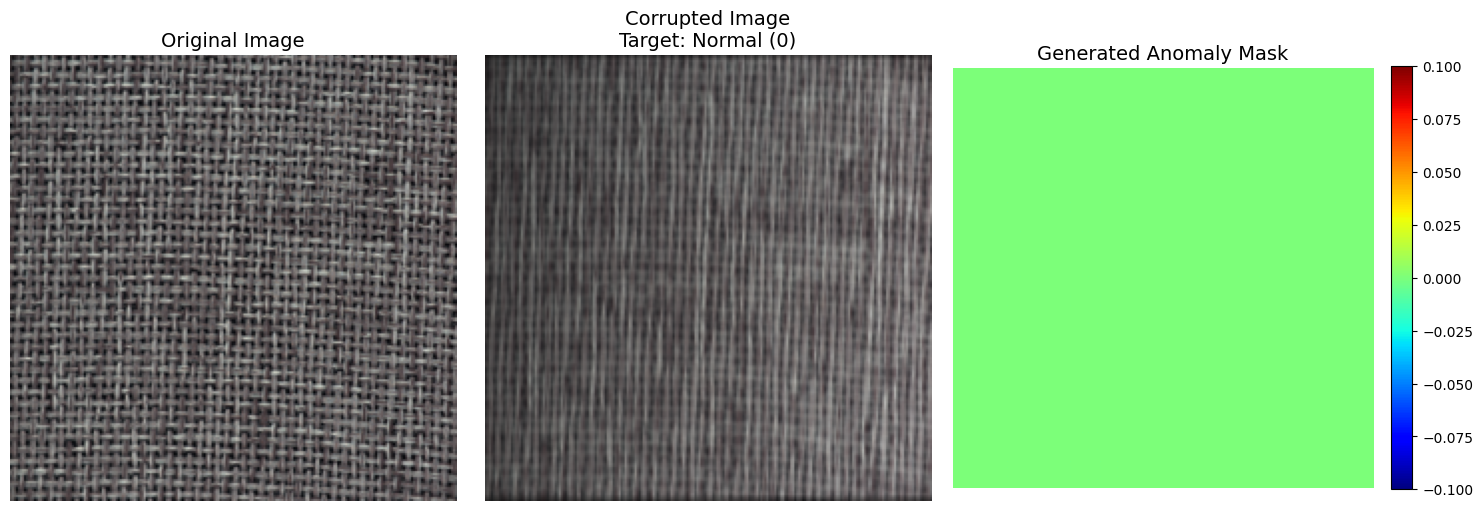

In [66]:
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
augmenter = OnGPUIndustrialAugmenter(
    masks_root_dir="dataset/masks",
    img_size=224, 
    p_anomaly=1.0,  # 1.0 لضمان ظهور الشذوذ في التجربة
    p_blur=1.0,     # 1.0 لضمان تطبيق الضبابية
    p_illum=1.0     # 1.0 لضمان تطبيق تدرج الإضاءة
).to(device)
def load_image(image_path, img_size=224):
    # قراءة الصورة وتحويلها لنظام ألوان RGB
    img = Image.open(image_path).convert('RGB')
    
    # تعريف التعديلات: تغيير الحجم + تحويل إلى Tensor (يقم بقسمة القيم على 255 تلقائياً)
    transform = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor() # المخرج يكون بأبعاد (C, H, W) والقيم بين 0.0 و 1.0
    ])
    
    img_tensor = transform(img)
    
    # إضافة بعد الدفعة (Batch Dimension) لتصبح الأبعاد (1, C, H, W)
    img_tensor = img_tensor.unsqueeze(0)
    return img_tensor, img

# استبدل 'your_image.jpg' بمسار الصورة لديك
image_path = r'F:\our_papers\eemfnet\datasets\mvtec_ad\carpet\train\good\000.png' 
input_tensor, original_pil_img = load_image(image_path, img_size=224)
input_tensor = input_tensor.to(device)

# -----------------------------------------------------------
# 3. تمرير الصورة عبر الموديل (Forward Pass)
# -----------------------------------------------------------
augmenter.eval() # وضع التقييم (رغم أن العمليات عشوائية داخلياً)
with torch.no_grad():
    corrupted_images, fault_masks, targets = augmenter(input_tensor)

# -----------------------------------------------------------
# 4. تحضير المخرجات للعرض (Postprocessing)
# -----------------------------------------------------------
# نقل البيانات إلى الـ CPU، إزالة بعد الدفعة (squeeze)، وتحويل الترتيب لـ Matplotlib (H, W, C)
corrupted_img_np = corrupted_images.squeeze(0).cpu().permute(1, 2, 0).numpy()
mask_np = fault_masks.squeeze().cpu().numpy() # القناع ذو بعد واحد للألوان (H, W)
target_label = "Defect (1)" if targets.item() == 1 else "Normal (0)"

# -----------------------------------------------------------
# 5. عرض النتائج باستخدام Matplotlib
# -----------------------------------------------------------
plt.figure(figsize=(15, 5))

# الصورة الأصلية بعد تغيير حجمها
plt.subplot(1, 3, 1)
plt.title("Original Image", fontsize=14)
plt.imshow(original_pil_img.resize((224, 224)))
plt.axis('off')

# الصورة المعدلة (محاكاة البيئة + العيوب)
plt.subplot(1, 3, 2)
plt.title(f"Corrupted Image\nTarget: {target_label}", fontsize=14)
plt.imshow(corrupted_img_np)
plt.axis('off')

# قناع الشذوذ (Anomaly Mask)
plt.subplot(1, 3, 3)
plt.title("Generated Anomaly Mask", fontsize=14)
plt.imshow(mask_np, cmap='jet') # استخدام خريطة ألوان jet لتوضيح مكان العيب بوضوح
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.tight_layout()
plt.show()

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class OnGPUIndustrialAugmenter(nn.Module):
    def __init__(self, img_size=224, p_anomaly=0.5, p_blur=0.3, p_illum=0.4):
        super().__init__()
        self.img_size = img_size
        self.p_anomaly = p_anomaly
        self.p_blur = p_blur
        self.p_illum = p_illum

    def _generate_gpu_perlin_mask(self, batch_size, device):
        """
        توليد أقنعة شذوذ مضلعة ومتعرجة (Polygonal & Jagged Masks) على الـ GPU مباشرة.
        تستخدم الضوضاء الزاوية (Angular Harmonic Noise) لمحاكاة الغلاف المحدب (Convex Hull)
        مع التبديل الديناميكي بين العيوب الكبيرة (Macro) والدقيقة (Micro).
        """
        h, w = self.img_size, self.img_size
        
        # 1. إنشاء شبكة الإحداثيات الكارتيزية لجميع صور الدفعة (B, 1, H, W)
        y_grid, x_grid = torch.meshgrid(
            torch.arange(h, device=device, dtype=torch.float32),
            torch.arange(w, device=device, dtype=torch.float32),
            indexing='ij'
        )
        x_grid = x_grid.unsqueeze(0).unsqueeze(0).expand(batch_size, 1, h, w)
        y_grid = y_grid.unsqueeze(0).unsqueeze(0).expand(batch_size, 1, h, w)
        
        # 2. التبديل العشوائي بين Macro (عيوب كبيرة) و Micro (عيوب صغيرة)
        is_macro = (torch.rand(batch_size, 1, 1, 1, device=device) > 0.5).float()
        
        # تحديد أنصاف الأقطار الأساسية
        min_r = max(4.0, h * 0.02)
        max_r_micro = max(10.0, h * 0.08)
        max_r_macro = h * 0.22
        
        radius_micro = torch.empty((batch_size, 1, 1, 1), device=device).uniform_(min_r, max_r_micro)
        radius_macro = torch.empty((batch_size, 1, 1, 1), device=device).uniform_(max_r_macro * 0.5, max_r_macro)
        base_radius = is_macro * radius_macro + (1 - is_macro) * radius_micro
        
        # 3. اختيار مراكز عشوائية للعيوب
        center_x = torch.empty((batch_size, 1, 1, 1), device=device).uniform_(w * 0.2, w * 0.8)
        center_y = torch.empty((batch_size, 1, 1, 1), device=device).uniform_(h * 0.2, h * 0.8)
        
        # 4. التحويل إلى إحداثيات قطبية (Polar Coordinates) لحساب الزاوية والمسافة
        dx = x_grid - center_x
        dy = y_grid - center_y
        dist = torch.sqrt(dx**2 + dy**2 + 1e-8)
        theta = torch.atan2(dy, dx) # الزاوية لكل بكسل من -pi إلى pi
        
        # 5. التلاعب الهندسي: إضافة ضوضاء زاوية (Angular Harmonics) لخلق زوايا المضلع والحواف المتعرجة
        # نولد 4 موجات جيبية عشوائية لكل صورة بترددات تمثل (عدد أضلاع/زوايا المضلع من 3 إلى 8 زوايا)
        num_harmonics = 4
        freqs = torch.randint(3, 9, (batch_size, num_harmonics, 1, 1), device=device).float()
        phases = torch.rand((batch_size, num_harmonics, 1, 1), device=device) * 2 * math.pi
        
        # قوة التعرج (Amplitudes): عيوب الـ Macro تكون أكثر تعرجاً وحداثة من الـ Micro
        amp_max = is_macro.view(batch_size, 1, 1, 1) * 0.18 + 0.08
        amps = torch.rand((batch_size, num_harmonics, 1, 1), device=device) * amp_max
        
        # حساب التعديل الزاوي عبر جمع الموجات (Broadcasting من B,4,H,W إلى B,1,H,W)
        angular_noise = torch.sum(amps * torch.sin(freqs * theta + phases), dim=1, keepdim=True)
        
        # نصف القطر الفعلي المعدل (يصبح مضلعاً بدلاً من دائرة)
        effective_radius = base_radius * (1.0 + angular_noise)
        
        # 6. إنشاء قناع المضلع الحاد الأساسي
        mask = (dist <= effective_radius).float()
        
        # 7. إضافة غلاف جاوس (Gaussian Envelope) للحفاظ على تدرج العمق في العيب
        env_multiplier = is_macro * 1.4 + (1 - is_macro) * 0.85
        env_radius = effective_radius * env_multiplier
        gaussian_envelope = torch.exp(-dist**2 / (2 * (env_radius**2) + 1e-8))
        mask = mask * gaussian_envelope
        
        # 8. تنعيم طفيف جداً (مرة واحدة فقط للـ Micro ومرتين للـ Macro) للحفاظ على حدة زوايا المضلع
        # هذا يمنع الحواف من أن تبدو "بيكسلية" (Aliased) ولكن يبقيها مضلعة وحادة
        mask = F.avg_pool2d(mask, kernel_size=3, stride=1, padding=1)
        mask_macro_blurred = F.avg_pool2d(mask, kernel_size=5, stride=1, padding=2)
        mask = is_macro * mask_macro_blurred + (1 - is_macro) * mask
        
        # 9. التطبيع والقص (Normalization & Clamping)
        max_vals = mask.view(batch_size, -1).max(dim=1)[0].view(batch_size, 1, 1, 1)
        mask = torch.where(max_vals > 0, mask / max_vals, mask)
        
        return mask.clamp(0.0, 1.0)

    def _apply_motion_blur(self, x):
        """
        محاكاة اهتزاز وحركة خط الإنتاج السريعة (Anisotropic Motion Blur)
        لتجنب الإنذارات الكاذبة الناتجة عن ضبابية الحركة.
        """
        if torch.rand(1).item() > self.p_blur:
            return x
        
        # إنشاء نواة حركة اتجاهية (أفقية أو رأسية تحاكي اتجاه سحب القماش)
        kernel_size = int(torch.randint(3, 9, (1,)).item()) | 1  # رقم فردي دائماً
        kernel = torch.zeros((1, 1, kernel_size, kernel_size), device=x.device)
        
        if torch.rand(1).item() > 0.5:
            kernel[0, 0, kernel_size // 2, :] = 1.0 / kernel_size  # حركة أفقية
        else:
            kernel[0, 0, :, kernel_size // 2] = 1.0 / kernel_size  # حركة رأسية
            
        kernel = kernel.repeat(x.shape[1], 1, 1, 1)
        # تطبيق الالتفاف مع الحفاظ على الأبعاد عبر التباديل والمجموعات
        x_blurred = F.conv2d(x, kernel, padding=kernel_size//2, groups=x.shape[1])
        return x_blurred

    def _apply_illumination_gradient(self, x):
        """
        محاكاة الظلال وتغير الإضاءة على القماش على خط الإنتاج.
        """
        if torch.rand(1).item() > self.p_illum:
            return x
            
        b, c, h, w = x.shape
        # إنشاء شبكة إحداثيات لظلال متدرجة
        y_grid, x_grid = torch.meshgrid(
            torch.linspace(-1, 1, h, device=x.device),
            torch.linspace(-1, 1, w, device=x.device),
            indexing='ij'
        )
        
        # اختيار زاوية عشوائية للظل
        angle = torch.rand(1, device=x.device) * 2 * math.pi
        gradient = (x_grid * torch.cos(angle) + y_grid * torch.sin(angle))
        
        # تطبيع التدرج وعمل تغيير طفيف في الإضاءة (بين 0.7 و 1.3)
        gradient = 0.7 + 0.6 * ((gradient - gradient.min()) / (gradient.max() - gradient.min() + 1e-8))
        gradient = gradient.unsqueeze(0).unsqueeze(0).expand_as(x)
        
        return torch.clamp(x * gradient, 0.0, 1.0)

    def forward(self, images, anomaly_textures=None):
        """
        images: صور الأقمشة النظيفة من الـ DataLoader بأبعاد (B, C, H, W)
        anomaly_textures: (اختياري) صور عيوب خارجية للدمج المنقول (TSA)
        """
        batch_size = images.shape[0]
        device = images.device
        
        # 1. محاكاة البيئة الصناعية على الصور النظيفة
        images = self._apply_illumination_gradient(images)
        images = self._apply_motion_blur(images)
        
        # 2. تحديد الصور التي سيتم حقن العيوب بها (50% من الدفعة افتراضياً)
        inject_mask = (torch.rand(batch_size, device=device) < self.p_anomaly).float().view(batch_size, 1, 1, 1)
        
        if inject_mask.sum() == 0:
            zeros_mask = torch.zeros((batch_size, 1, self.img_size, self.img_size), device=device)
            return images, zeros_mask, torch.zeros(batch_size, device=device)
            
        # 3. توليد قناع الشذوذ السريع
        fault_masks = self._generate_gpu_perlin_mask(batch_size, device) * inject_mask
        
        # 4. حقن الشذوذ (إذا لم تتوفر صور خارجية، يتم تشويه النسيج نفسه عبر تعكير اللون وحافة التباين)
        if anomaly_textures is not None and anomaly_textures.shape[0] == batch_size:
            corrupted_images = images * (1 - fault_masks) + anomaly_textures * fault_masks
        else:
            # محاكاة التمزق والبقع الداكنة/الفاتحة عبر قلب التباين أو إضافة لون شاذ
            color_shift = torch.randn((batch_size, images.shape[1], 1, 1), device=device) * 0.5
            corrupted_images = images * (1 - fault_masks) + torch.clamp(images + color_shift, 0, 1) * fault_masks
            
        # المخرجات: الصور المعدلة، الأقنعة الناتجة، وتصنيف الدفعة (0 سليم، 1 معيب)
        targets = (fault_masks.view(batch_size, -1).max(dim=1)[0] > 0).long()
        return corrupted_images, fault_masks, targets

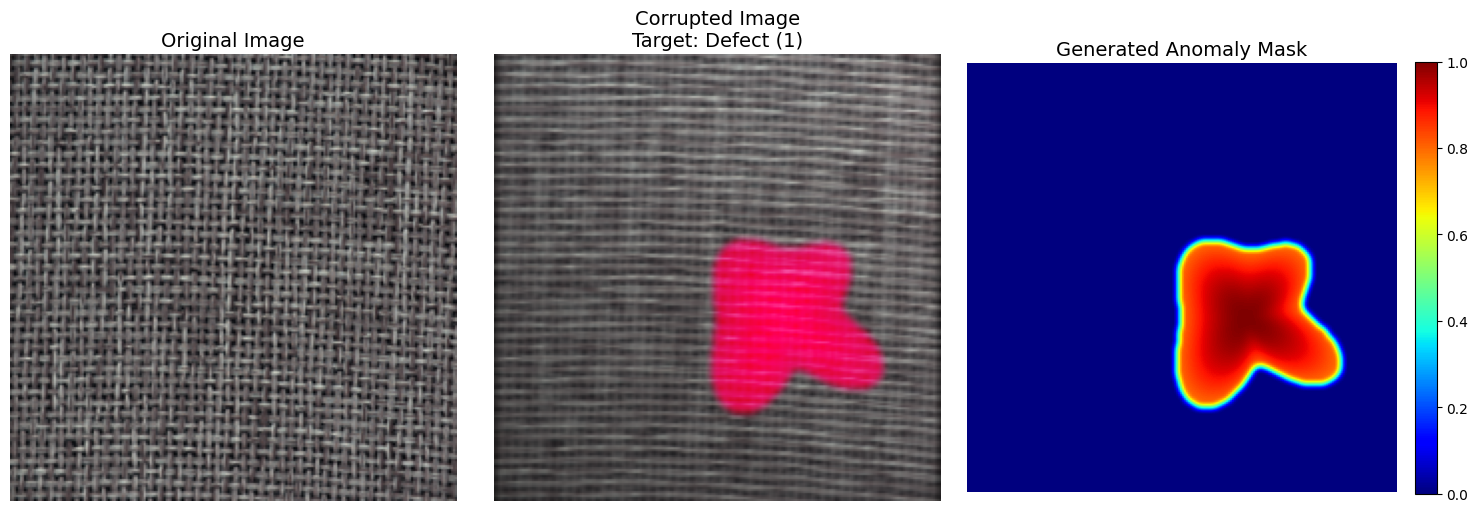

In [65]:
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
augmenter = OnGPUIndustrialAugmenter(
    img_size=224, 
    p_anomaly=1.0,  # 1.0 لضمان ظهور الشذوذ في التجربة
    p_blur=1.0,     # 1.0 لضمان تطبيق الضبابية
    p_illum=1.0     # 1.0 لضمان تطبيق تدرج الإضاءة
).to(device)
def load_image(image_path, img_size=224):
    # قراءة الصورة وتحويلها لنظام ألوان RGB
    img = Image.open(image_path).convert('RGB')
    
    # تعريف التعديلات: تغيير الحجم + تحويل إلى Tensor (يقم بقسمة القيم على 255 تلقائياً)
    transform = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor() # المخرج يكون بأبعاد (C, H, W) والقيم بين 0.0 و 1.0
    ])
    
    img_tensor = transform(img)
    
    # إضافة بعد الدفعة (Batch Dimension) لتصبح الأبعاد (1, C, H, W)
    img_tensor = img_tensor.unsqueeze(0)
    return img_tensor, img

# استبدل 'your_image.jpg' بمسار الصورة لديك
image_path = r'F:\our_papers\eemfnet\datasets\mvtec_ad\carpet\train\good\000.png' 
input_tensor, original_pil_img = load_image(image_path, img_size=224)
input_tensor = input_tensor.to(device)

# -----------------------------------------------------------
# 3. تمرير الصورة عبر الموديل (Forward Pass)
# -----------------------------------------------------------
augmenter.eval() # وضع التقييم (رغم أن العمليات عشوائية داخلياً)
with torch.no_grad():
    corrupted_images, fault_masks, targets = augmenter(input_tensor)

# -----------------------------------------------------------
# 4. تحضير المخرجات للعرض (Postprocessing)
# -----------------------------------------------------------
# نقل البيانات إلى الـ CPU، إزالة بعد الدفعة (squeeze)، وتحويل الترتيب لـ Matplotlib (H, W, C)
corrupted_img_np = corrupted_images.squeeze(0).cpu().permute(1, 2, 0).numpy()
mask_np = fault_masks.squeeze().cpu().numpy() # القناع ذو بعد واحد للألوان (H, W)
target_label = "Defect (1)" if targets.item() == 1 else "Normal (0)"

# -----------------------------------------------------------
# 5. عرض النتائج باستخدام Matplotlib
# -----------------------------------------------------------
plt.figure(figsize=(15, 5))

# الصورة الأصلية بعد تغيير حجمها
plt.subplot(1, 3, 1)
plt.title("Original Image", fontsize=14)
plt.imshow(original_pil_img.resize((224, 224)))
plt.axis('off')

# الصورة المعدلة (محاكاة البيئة + العيوب)
plt.subplot(1, 3, 2)
plt.title(f"Corrupted Image\nTarget: {target_label}", fontsize=14)
plt.imshow(corrupted_img_np)
plt.axis('off')

# قناع الشذوذ (Anomaly Mask)
plt.subplot(1, 3, 3)
plt.title("Generated Anomaly Mask", fontsize=14)
plt.imshow(mask_np, cmap='jet') # استخدام خريطة ألوان jet لتوضيح مكان العيب بوضوح
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.tight_layout()
plt.show()